## TabFM Model – 1.0.0

### Description:

In this notebook I will build a classification and regression model using the TabFM foundation model. TabFM is a zero-shot tabular foundation model from Google Research. It supports classification and regression on structured data with mixed numerical and categorical columns without requiring fine-tuning or hyperparameter search, training examples are passed as context, and predictions are made in a single forward pass.


In [2]:
## This notebook is designed to be run on a local machine as well as Google Colab
# Base on the running platform, imports and file paths may change. To solve this, the running_local variable will be used to easily change the running platform logic.
running_local = True


## 1.0 Import  libraries

In [3]:
# utils folder is in the root, the notebook cannot unless the root path is added to the notebook.
############ import utils from if running from local machine ###########
if running_local:
    import sys
    sys.path.append('..')
    from utils.data_utils import get_model_metrics, predict_with_threshold, evaluate_regression_model
else:
    ###############################################################

    ################################################################
    ####################### GOOGLE COLAB RUN #######################
    ### Utils file is not available if running on Colab. I need to clone the repo to use the data_utils.py
    !git clone https://github.com/weslylaboy/student-outcome-predictor.git
    import sys
    sys.path.insert(0, '/content/student-outcome-predictor')
    from utils.data_utils import get_model_metrics, predict_with_threshold, evaluate_regression_model

    ########################################

import pandas as pd
from sklearn.model_selection import train_test_split
from tabfm import TabFMClassifier, tabfm_v1_0_0_pytorch as tabfm_v1_0_0
import torch
import joblib




### 1.1 Load data

The cleaned data was saved to `./data/processed/02.7_data_final.csv`. I will load this dataset for our modeling process.


In [3]:
if running_local:
    ##### import data file if running on local machine
    df = pd.read_csv('../data/processed/02.7_data_final.csv')
else:
    ##################### GOOGLE COLAB ################################
    ### Data location is different if running on colab
    df = pd.read_csv('/content/student-outcome-predictor/data/processed/02.7_data_final.csv')
    ###################################################################

df.head()

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


### 1.2 Fix Datatypes

In [4]:
# Fix int datatypes
int_cols = ['displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international', 'daytime_evening', 'age_at_enrollment', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_no_evaluations', 'cu2_credited', 'cu2_enrolled', 'cu2_evaluations', 'cu2_approved', 'cu2_no_evaluations', 'total_approved_units', 'prev_qualification']
df[int_cols] = df[int_cols].astype('int8')

# additional engineered features
unknown_flags = [
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown',
    'any_info_missing'
]

df[unknown_flags] = df[unknown_flags].astype('int8')

# target variable
df['target_encoded'] = df['target_encoded'].astype('int8')


####### Fix binary data types
categorical_cols = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# new engineered feature as category
df['age_group'] = df['age_group'].astype('category')

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   int8    
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


***Interpretation:*** I have fix the datatypes for all columns in dataset.

### 1.3 Data Preparation: Remove Target Columns

In this step I will separate the features from the target columns. Also, I will filter out `Enrolled` students as these students will be used to deploy the model. So, the model will be trained using students with status `Graduate` or `Dropout`.

In [5]:
# create a copy excluding students with status Enrolled
df_baseline = df[df['target_encoded'] != 1].copy()

# define features and target
X = df_baseline.drop(['target', 'target_encoded'], axis=1)

# update the encoded values to mapping it to 0 and 1
# 0 = Dropout, 1 = Graduate to have a clean binary column.
y = df_baseline['target_encoded'].map({0:0, 2:1})
X.shape, y.shape


((3630, 45), (3630,))

***Interpretation:*** The final dataset contains `3,630 rows`, `45 features`, and `1 target` variable.

In [6]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

(((2904, 45), (2904,)), ((726, 45), (726,)))

## 2.0 Tab FM Classification Model

### 2.1 Pytorch Backend

In [7]:
model = tabfm_v1_0_0.load(checkpoint_path="../models/tabfm/classification/pytorch_model.bin", model_type="classification")

# The model object is a PyTorch Module, move it directly to MPS
# if torch.backends.mps.is_available():
#     model.to("mps")
#     print("Model moved to MPS (Mac GPU)")
# else:
#     print("MPS not available, using CPU")

clf = TabFMClassifier(model=model)
clf.fit(X_train, y_train)
clf


TabFMClassifier(model=TabFM(
  (cell_embedder): CellEmbedder(
    (in_linear): Linear(in_features=64, out_features=256, bias=True)
    (in_linear_cat): Linear(in_features=64, out_features=256, bias=True)
    (y_embedder_lookup): Embedding(10, 256)
  )
  (col_embedder): ColEmbedding(
    (tf_col): SetTransformer(
      (blocks): ModuleList(
        (0-2): 3 x InducedSelfAttentionBlock(
          (mab1): MultiheadAttenti...
          (linear1_gate): Linear(in_features=2048, out_features=8192, bias=True)
          (linear2): Linear(in_features=8192, out_features=2048, bias=True)
        )
      )
    )
    (ln): RMSNorm()
    (y_encoder): OneHotAndLinear(
      (projection): Linear(in_features=10, out_features=2048, bias=True)
    )
    (decoder): MLP(
      (layers): ModuleList(
        (0): Linear(in_features=2048, out_features=4096, bias=True)
        (1): Linear(in_features=4096, out_features=10, bias=True)
      )
    )
  )
))

TabFM Classification Model (Threshold 0.4): evaluation results
              precision    recall  f1-score   support

     Dropout       0.94      0.87      0.90       284
    Graduate       0.92      0.96      0.94       442

    accuracy                           0.92       726
   macro avg       0.93      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



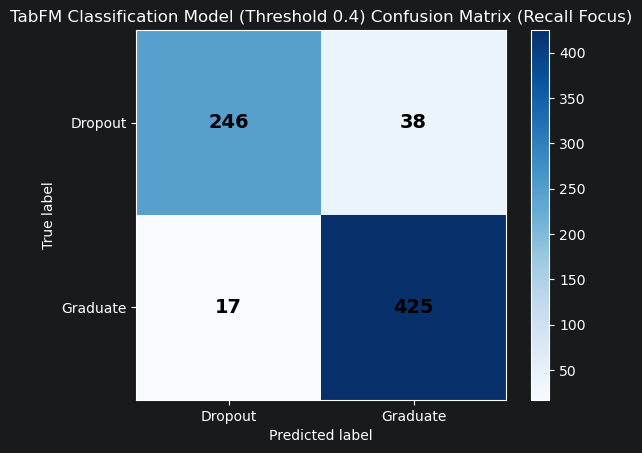

In [10]:
custom_threshold = 0.4
y_pred_classification = predict_with_threshold(clf, X_test, y_test, threshold=custom_threshold, model_name='TabFM Classification Model')

***Interpretation:*** The TabFM classification model performed really well, it have the best `recall` for `Dropout` class with `87%` compared to the `86%` recall for the XGBoost model. The TabFM model correctly identified `246 Dropout` and missclassifiying only `38 Dropouts` as `Graduate`, the XGBoost model correctly identified `245` and misclassified `38` `Dropout`.

The improvements are not really noticeable compared to the XGBoost model for this dataset. I would still choose the XGBoost model for this task as the XGBoost model predictions was faster than the TabFM. The TabFM model took `44 minutes` to generate predictions for `726 students`, the XGBoost model took less than a minute to generate the same predictions.

Since the TabFM model didn't show lots of improvements in performance and took more time to predict than the XGBoost model, I will keep using the XGBoost model to predict student outcome.

### 2.2 Saving Classification Model Result

In [11]:
results_models_metrics = []

results_models_metrics.append(get_model_metrics(y_test, y_pred_classification, 'Tab FM Classification'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Tab FM Classification,0.9242,0.9354,0.8662,0.8995,0.9179,0.9615,0.9392


***Interpretation:***

### 3.0 TabFM Regression Model

### 3.1 Load data

To do a fair comparison of the regression model, I will use the classification model selected in the classification notebook. This model is saved in the `models` folders. I will import this model to identify the students at risk of `Dropout` and then use the TabFM regression model to predict the `GPA` for those students at risk.

In [ ]:
# Load your saved pipeline
clf_model = joblib.load("../models/student_outcome_prediction_model.joblib")


clf_model

***Interpretation:*** I have loaded both the dataset and the classification model. The classification model was saved at the end of notebook 03 and I need it here to generate dropout probabilities for each student. The dataset has `47 columns` and the `target` for this notebook is `cu2_grade`, which is the average grade a student got in their second semester on a scale from `0 to 20`.


### 3.1 Filter At Risk Students

This regression model is not meant for all students. It is specifically for students the classification model already identified as dropout risks. The logic is:

1. The classification model tells us who is at risk
2. This regression model then asks: among those students, how is their academic performance and what is causing it

I will also remove invalid grade for students with `cu2_grade = 0`. Those are mostly students who dropped out and never took the exams, so their zero does not represent actual academic performance, it just means they stopped attending.

I will also use the same threshold of `0.4` used for the classification method. This threshold will be used to capture the students with `40%` probability of dropping out.


In [ ]:
target = 'cu2_grade'

# filter invalid grade cu_grade = 0
df_valid = df[df[target] > 0].copy()

# get dropout probability from the classification model for all valid students
dropout_proba = clf_model.predict_proba(df_valid)[:, 0]
df_valid['dropout_probability'] = dropout_proba

# Keep only students flagged as at risk (dropout probability >= 0.4)
df_at_risk = df_valid[df_valid['dropout_probability'] >= 0.4].copy()

print(f"Total students in dataset           : {len(df)}")
print(f"Students with valid cu2_grade       : {len(df_valid)}")
print(f"Students flagged as dropout risk    : {len(df_at_risk)}")
print(f"\nGrade distribution for at risk students:")
df_at_risk[target].describe().round(4)


***Interpretation:*** The classification model found that the dataset contains `4,424` students. From those students, `3,554` had a valid target variable (`cu2_grade`), it must be a positive non-zero number. A value of `0` for `cu2_grade` indicate the student stop showing up to classes. The model classified `1,011` students at risk of dropout.

The grade `cu2_grade` goes from `0 to 20`, for the students flagged as risk the `mean` is `11.96`, the `min` value is `10.00`, and the `max` is `17.43`. The `std` is `1.36`, and the `50%` of student as risk are about `11.75`.

### 3.2 Train-Test split

In this step, I will split the student at risk data into training and test sets.


In [ ]:
X = df_at_risk.drop(columns=['cu2_grade'])
y = df_at_risk['cu2_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} students")
print(f"Test set     : {X_test.shape[0]} students")


***Interpretation*** The training set have `808` students, and the test set have `203` students.

### 3.4 Building the TabFM Regression Model

In [ ]:
reg_model = tabfm_v1_0_0.load(model_type="regression", checkpoint_path='../models/tabfm/regression/pytorch_model.bin')

reg_model.fit(X_train, y_train)
reg_model

In [ ]:
results = {}

y_pred_reg = evaluate_regression_model('TabFM Regression Model', reg_model, X_test, y_test, results)

pd.DataFrame(results)

## Analysis of Results and Conclusions

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work
